# Random Forest Classifier on SMILES ChemNet Embeddings

### Basic Preprocessing

In [2]:
# Import packages
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [5]:
# The 5/20 dataset with rat based toxicity data
df2 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data2.csv")
print(df2.shape)
df2.head() 

(3068, 12)


,SMILES_spectra,CAS,Molecular_Formula,Precursor_m/z,Spectrum,Ionization_Mode,Instrument_Type,Collision_Energy,SMILES_tox,Response_Modifier,Response,Response_Unit
0,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','64.0067:0.816052 65.0145:5.320549 66.0098:18....,'negative','LC-ESI-QFT','90','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'
1,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','64.0066:0.313715 65.0145:2.298303 66.0098:3.8...,'negative','LC-ESI-QFT','75','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'
2,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','64.0065:0.181194 65.0145:0.527326 66.0097:0.6...,'negative','LC-ESI-QFT','60','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'
3,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','64.0065:0.132092 65.0145:0.255012 69.0346:0.6...,'negative','LC-ESI-QFT','45','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'
4,'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','87-42-3','C10H9N5O','214.0734','69.0346:0.347949 92.0255:0.566186 106.0284:0....,'negative','LC-ESI-QFT','30','C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1','>',5000.0,'mg/kg'


In [6]:
# Uniformity of ionization model labels
print(df2["Ionization_Mode"].unique())
df2["Ionization_Mode"] = df2["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df2["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df2 = df2[df2["Ionization_Mode"] != "'N/A'"]
print(df2["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df2
df2 = df2.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df2["SMILES_spectra"] = df2["SMILES_spectra"].str.replace("'", "")
df2.head()

["'negative'" "'positive'" "'Positive'" "'N/A'"]
["'negative'" "'positive'" "'N/A'"]
["'negative'" "'positive'"]


,SMILES_spectra,CAS,Molecular_Formula,Precursor_m/z,Spectrum,Ionization_Mode,Instrument_Type,Collision_Energy,SMILES_tox,Response_Modifier,Response,Response_Unit
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0067:0.816052 65.0145:5.320549 66.0098:18.7...,negative,LC-ESI-QFT,90,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
1,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0066:0.313715 65.0145:2.298303 66.0098:3.87...,negative,LC-ESI-QFT,75,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
2,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0065:0.181194 65.0145:0.527326 66.0097:0.68...,negative,LC-ESI-QFT,60,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0065:0.132092 65.0145:0.255012 69.0346:0.65...,negative,LC-ESI-QFT,45,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,69.0346:0.347949 92.0255:0.566186 106.0284:0.2...,negative,LC-ESI-QFT,30,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg


In [7]:
# Count unique SMILES in the DataFrame
unique_smiles_count = df2["SMILES_spectra"].nunique()
# Count how many SMILES have more than 20, 10, and 5 corresponding rows
smiles_counts = df2["SMILES_spectra"].value_counts()
more_than_20 = (smiles_counts > 20).sum()
more_than_10 = (smiles_counts > 10).sum()
more_than_5 = (smiles_counts > 5).sum()
more_than_1 = (smiles_counts > 1).sum()
just_1 = (smiles_counts == 1).sum()

# Print the results
print("Number of unique SMILES:", unique_smiles_count)
print("SMILES with >20 rows:", more_than_20)
print("SMILES with >10 rows:", more_than_10)
print("SMILES with >5 rows:", more_than_5)
print("SMILES with >1 rows:", more_than_1)
print("SMILES with 1 row:", just_1)



Number of unique SMILES: 347
SMILES with >20 rows: 21
SMILES with >10 rows: 94
SMILES with >5 rows: 247
SMILES with >1 rows: 331
SMILES with 1 row: 16


### Save ChemNet Dataframe for 5/20 dataset

In [8]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [9]:
# Get the ChemNet embeddings for the SMILES in df2
ChemNet_df2_dict = get_chemnet_emb_from_smiles(df2["SMILES_spectra"].tolist())


/home/dlipsey/.local/lib/python3.8/site-packages/fcd_torch/fcd.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  keras_config = torch.load(model_path)


In [10]:
# Convert the dictionary to a DataFrame
ChemNet_df2 = pd.DataFrame.from_dict(ChemNet_df2_dict, orient='index')
# Name the first column to "SMILES" and check the dataframe
ChemNet_df2.reset_index(inplace=True)
ChemNet_df2.rename(columns={'index': 'SMILES'}, inplace=True)
ChemNet_df2.head()

,SMILES,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343494,0.000665,0.109528,0.623215,-0.109778,0.112946,-0.418191,-0.035476,-0.004837,...,0.001494,-0.356015,0.435768,-1.227300e-03,0.135895,0.161929,0.331091,0.624196,0.150649,0.398507
1,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178073,0.005417,0.428171,0.479712,-0.162719,0.033272,-0.322656,-0.034891,-0.049518,...,0.002962,0.204102,0.215906,-1.736291e-02,0.542236,0.477791,-0.102516,0.484791,0.349672,-0.029118
2,C1=CC(=CC=N1)C1=CC=NC=C1,0.340498,0.000491,-0.096003,0.602184,-0.004242,0.101529,0.200828,-0.061072,-0.239719,...,0.034534,-0.191646,0.951772,8.518275e-07,-0.169939,-0.143716,-0.217223,-0.283386,0.141254,0.285106
3,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172673,0.001336,0.185543,0.693660,-0.003303,0.163667,0.365009,-0.086592,-0.362325,...,0.001197,0.117902,0.938238,-2.607757e-03,-0.428630,-0.166449,-0.151636,0.001726,0.223620,0.140640
4,C1CCC(CC1)NC1CCCCC1,-0.162907,-0.001073,-0.013219,0.099288,-0.102379,0.188370,-0.264037,-0.093580,-0.099299,...,0.140565,-0.014874,0.105914,1.399292e-04,-0.309628,-0.002650,0.027983,-0.137531,0.018759,-0.080645


In [ ]:
# Save the ChemNet embeddings to a CSV file
# ChemNet_df2.to_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_df2.csv", index=False)

In [15]:
# Read in the csv file with the ChemNet embeddings
ChemNet_df2 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_df2.csv")
ChemNet_df2.head()

,SMILES,0,1,2,3,4,5,6,7,8,...,502,503,504,505,506,507,508,509,510,511
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343494,0.000665,0.109528,0.623215,-0.109778,0.112946,-0.418191,-0.035476,-0.004837,...,0.001494,-0.356015,0.435768,-1.227300e-03,0.135895,0.161929,0.331091,0.624196,0.150649,0.398507
1,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178073,0.005417,0.428171,0.479712,-0.162719,0.033272,-0.322656,-0.034891,-0.049518,...,0.002962,0.204102,0.215906,-1.736291e-02,0.542236,0.477791,-0.102516,0.484791,0.349672,-0.029118
2,C1=CC(=CC=N1)C1=CC=NC=C1,0.340498,0.000491,-0.096003,0.602184,-0.004242,0.101529,0.200828,-0.061072,-0.239719,...,0.034534,-0.191646,0.951772,8.518274e-07,-0.169939,-0.143715,-0.217223,-0.283386,0.141254,0.285106
3,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172673,0.001336,0.185543,0.693660,-0.003303,0.163667,0.365009,-0.086592,-0.362325,...,0.001197,0.117902,0.938238,-2.607757e-03,-0.428630,-0.166449,-0.151636,0.001726,0.223620,0.140640
4,C1CCC(CC1)NC1CCCCC1,-0.162908,-0.001073,-0.013219,0.099288,-0.102379,0.188370,-0.264037,-0.093580,-0.099299,...,0.140565,-0.014874,0.105914,1.399292e-04,-0.309628,-0.002650,0.027983,-0.137531,0.018759,-0.080645


In [16]:
df2.head(10)

,SMILES_spectra,CAS,Molecular_Formula,Precursor_m/z,Spectrum,Ionization_Mode,Instrument_Type,Collision_Energy,SMILES_tox,Response_Modifier,Response,Response_Unit
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0067:0.816052 65.0145:5.320549 66.0098:18.7...,negative,LC-ESI-QFT,90,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
1,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0066:0.313715 65.0145:2.298303 66.0098:3.87...,negative,LC-ESI-QFT,75,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
2,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0065:0.181194 65.0145:0.527326 66.0097:0.68...,negative,LC-ESI-QFT,60,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,64.0065:0.132092 65.0145:0.255012 69.0346:0.65...,negative,LC-ESI-QFT,45,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,69.0346:0.347949 92.0255:0.566186 106.0284:0.2...,negative,LC-ESI-QFT,30,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
5,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,214.0734,92.0254:0.109265 107.0364:0.152054 117.0202:0....,negative,LC-ESI-QFT,15,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
6,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,216.088,53.0386:30.075814 67.0291:0.287672 70.0651:0.2...,positive,LC-ESI-QFT,90,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
7,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,216.088,53.0386:14.145079 70.0651:0.238628 80.0495:0.1...,positive,LC-ESI-QFT,75,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
8,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,216.088,53.0386:5.979920 70.0652:0.132712 81.0335:100....,positive,LC-ESI-QFT,60,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg
9,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,87-42-3,C10H9N5O,216.088,53.0386:2.110021 81.0334:100.000000 119.0352:0...,positive,LC-ESI-QFT,45,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,>,5000.0,mg/kg


In [17]:
# Append the response column to the ChemNet DataFrame
# First remove all redundant SMILES from df2
df2_unique_smiles = df2.drop_duplicates(subset=["SMILES_spectra"])
# Merge Response from df2_unique_smiles onto ChemNet_df2 by matching SMILES columns
ChemNet_df2_withtox = ChemNet_df2.merge(
    df2_unique_smiles[['SMILES_spectra', 'Response']],
    left_on='SMILES',
    right_on='SMILES_spectra',
    how='left'
)

# Optionally, drop the now-redundant 'SMILES_spectra' column
ChemNet_df2_withtox.drop(columns=['SMILES_spectra'], inplace=True)


In [18]:
print(ChemNet_df2_withtox.shape)
ChemNet_df2_withtox.head()

(347, 514)


,SMILES,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,Response
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343494,0.000665,0.109528,0.623215,-0.109778,0.112946,-0.418191,-0.035476,-0.004837,...,-0.356015,0.435768,-1.227300e-03,0.135895,0.161929,0.331091,0.624196,0.150649,0.398507,5000.0
1,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178073,0.005417,0.428171,0.479712,-0.162719,0.033272,-0.322656,-0.034891,-0.049518,...,0.204102,0.215906,-1.736291e-02,0.542236,0.477791,-0.102516,0.484791,0.349672,-0.029118,1640.0
2,C1=CC(=CC=N1)C1=CC=NC=C1,0.340498,0.000491,-0.096003,0.602184,-0.004242,0.101529,0.200828,-0.061072,-0.239719,...,-0.191646,0.951772,8.518274e-07,-0.169939,-0.143715,-0.217223,-0.283386,0.141254,0.285106,172.0
3,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172673,0.001336,0.185543,0.693660,-0.003303,0.163667,0.365009,-0.086592,-0.362325,...,0.117902,0.938238,-2.607757e-03,-0.428630,-0.166449,-0.151636,0.001726,0.223620,0.140640,1463.0
4,C1CCC(CC1)NC1CCCCC1,-0.162908,-0.001073,-0.013219,0.099288,-0.102379,0.188370,-0.264037,-0.093580,-0.099299,...,-0.014874,0.105914,1.399292e-04,-0.309628,-0.002650,0.027983,-0.137531,0.018759,-0.080645,373.0


### One hot encode toxicity

The EPA toxicity criteria consist of 4 levels:
1. Up to and includeing 50 mg/kg
2. From 50 through 500 mg/kg
3. From 500 though 5000 mg/kg
4. Greater than 5000 mg/kg

In [19]:
# Define a function to assign EPA levels
def assign_epa_level(response):
    if response <= 50:
        return "EPA_level_1"
    elif response <= 500:
        return "EPA_level_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"



In [20]:
# Initialize a new DataFrame for the EPA levels
ChemNet_df2_epalevels = ChemNet_df2_withtox.copy()

# Assign EPA levels
ChemNet_df2_epalevels["EPA_level"] = ChemNet_df2_withtox["Response"].apply(assign_epa_level)

# One hot encode the EPA_level column
ChemNet_df2_epalevels = pd.get_dummies(ChemNet_df2_epalevels, columns=["EPA_level"], prefix='',prefix_sep='')

# Convert boolean columns to int (1/0)
epa_cols = [col for col in ChemNet_df2_epalevels.columns if col.startswith("EPA_level_")]
ChemNet_df2_epalevels[epa_cols] = ChemNet_df2_epalevels[epa_cols].astype(int)

# Remove the Response column
ChemNet_df2_epalevels.drop(columns=["Response"], inplace=True)

# Check the shape and head of the DataFrame
print(ChemNet_df2_epalevels.shape)
ChemNet_df2_epalevels.head()

(347, 517)


,SMILES,0,1,2,3,4,5,6,7,8,...,506,507,508,509,510,511,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.343494,0.000665,0.109528,0.623215,-0.109778,0.112946,-0.418191,-0.035476,-0.004837,...,0.135895,0.161929,0.331091,0.624196,0.150649,0.398507,0,0,1,0
1,C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1,-0.178073,0.005417,0.428171,0.479712,-0.162719,0.033272,-0.322656,-0.034891,-0.049518,...,0.542236,0.477791,-0.102516,0.484791,0.349672,-0.029118,0,0,1,0
2,C1=CC(=CC=N1)C1=CC=NC=C1,0.340498,0.000491,-0.096003,0.602184,-0.004242,0.101529,0.200828,-0.061072,-0.239719,...,-0.169939,-0.143715,-0.217223,-0.283386,0.141254,0.285106,0,1,0,0
3,C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1,0.172673,0.001336,0.185543,0.693660,-0.003303,0.163667,0.365009,-0.086592,-0.362325,...,-0.428630,-0.166449,-0.151636,0.001726,0.223620,0.140640,0,0,1,0
4,C1CCC(CC1)NC1CCCCC1,-0.162908,-0.001073,-0.013219,0.099288,-0.102379,0.188370,-0.264037,-0.093580,-0.099299,...,-0.309628,-0.002650,0.027983,-0.137531,0.018759,-0.080645,0,1,0,0


In [21]:
# Lets get counfst of each EPA level
# Count the number of entries at each EPA_level
epa_level_cols = [col for col in ChemNet_df2_epalevels.columns if col.startswith("EPA_level_")]
epa_level_counts = ChemNet_df2_epalevels[epa_level_cols].sum()
print(epa_level_counts)

EPA_level_1      6
EPA_level_2     73
EPA_level_3    207
EPA_level_4     61
dtype: int64


### Train a Random Forest Classifier

In [22]:
# Load the needed packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# Prepare features (X) and labels (y)
# Drop SMILES and keep only embedding columns for X, and EPA levels for y
embedding_cols = [col for col in ChemNet_df2_epalevels.columns if col not in ['SMILES'] + [col for col in ChemNet_df2_epalevels.columns if col.startswith('EPA_level_')]]
epa_level_cols = [col for col in ChemNet_df2_epalevels.columns if col.startswith('EPA_level_')]

X = ChemNet_df2_epalevels[embedding_cols]
y = ChemNet_df2_epalevels[epa_level_cols].idxmax(axis=1)  # Get the EPA level label

In [23]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
0,0.343494,0.000665,0.109528,0.623215,-0.109778,0.112946,-0.418191,-0.035476,-0.004837,0.071298,...,0.001494,-0.356015,0.435768,-1.227300e-03,0.135895,0.161929,0.331091,0.624196,0.150649,0.398507
1,-0.178073,0.005417,0.428171,0.479712,-0.162719,0.033272,-0.322656,-0.034891,-0.049518,0.098473,...,0.002962,0.204102,0.215906,-1.736291e-02,0.542236,0.477791,-0.102516,0.484791,0.349672,-0.029118
2,0.340498,0.000491,-0.096003,0.602184,-0.004242,0.101529,0.200828,-0.061072,-0.239719,-0.657409,...,0.034534,-0.191646,0.951772,8.518274e-07,-0.169939,-0.143715,-0.217223,-0.283386,0.141254,0.285106
3,0.172673,0.001336,0.185543,0.693660,-0.003303,0.163667,0.365009,-0.086592,-0.362325,-0.214736,...,0.001197,0.117902,0.938238,-2.607757e-03,-0.428630,-0.166449,-0.151636,0.001726,0.223620,0.140640
4,-0.162908,-0.001073,-0.013219,0.099288,-0.102379,0.188370,-0.264037,-0.093580,-0.099299,0.273349,...,0.140565,-0.014874,0.105914,1.399292e-04,-0.309628,-0.002650,0.027983,-0.137531,0.018759,-0.080645


In [24]:
print(y)

0      EPA_level_3
1      EPA_level_3
2      EPA_level_2
3      EPA_level_3
4      EPA_level_2
          ...     
342    EPA_level_4
343    EPA_level_2
344    EPA_level_2
345    EPA_level_2
346    EPA_level_3
Length: 347, dtype: object


In [25]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=None, max_features='sqrt', random_state=47)
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf.predict(X_test)

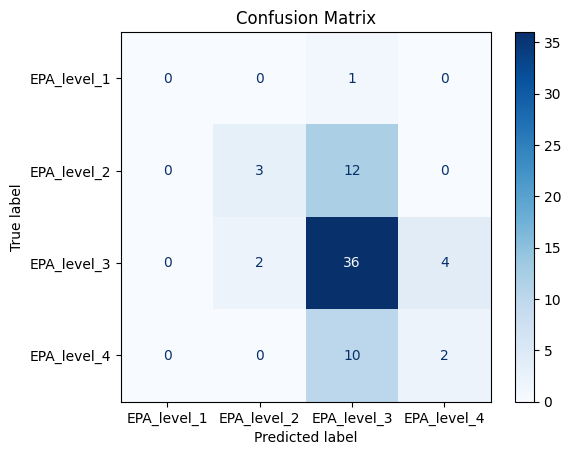

In [26]:
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [35]:
# Balances 4 way Random Forest Classifier
# Set the target number of samples per class
target_count = 35
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

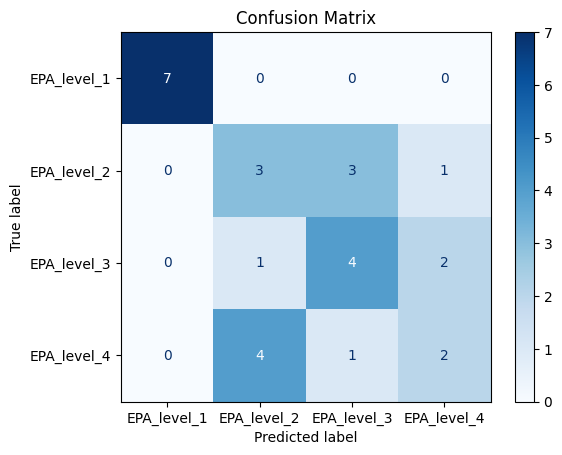

In [36]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Fitting 5 folds for each of 24 candidates, totalling 120 fits


[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, max

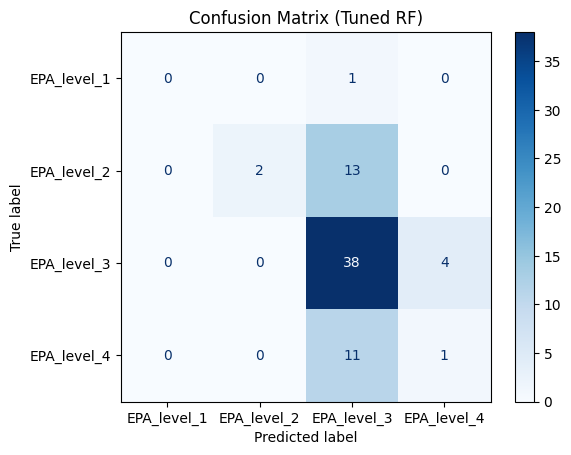

In [28]:
# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=47)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', # Use macro F1 score for multi-class classification
    n_jobs=-1,
    verbose=2
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Use the best estimator to predict and evaluate
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Tuned RF)")
plt.show()


In [29]:
# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 200}
Best cross-validation accuracy: 0.2747898295508435


Do the hyperparameter search with F1 score due to imbalance in the data causign inflated accuracy. 
Consider 1 union 2 


### Binary classifcation problem

We can make this a binary classfication problem and mitigate some of the imbalance issues that we saw if we remove the EPA level 3 and combine levels 1 and 2. Is this a reasonable think to do form a chemistry standpoint?

In [30]:
# Combine EPA_level_1 and EPA_level_2 into EPA_level_1_2, remove EPA_level_3, keep only EPA_level_1_2 and EPA_level_4

df = ChemNet_df2_epalevels.copy()

# Create new binary label
def combine_epa_levels(row):
    if row['EPA_level_1'] == 1 or row['EPA_level_2'] == 1:
        return 'EPA_level_1_2'
    elif row['EPA_level_4'] == 1:
        return 'EPA_level_4'
    else:
        return None  # EPA_level_3 or anything else

df['EPA_binary'] = df.apply(combine_epa_levels, axis=1)

# Filter out rows that are not EPA_level_1_2 or EPA_level_4
df_bin = df[df['EPA_binary'].isin(['EPA_level_1_2', 'EPA_level_4'])].copy()

# Prepare features and labels
embedding_cols = [col for col in df_bin.columns if col not in ['SMILES', 'EPA_binary'] + [col for col in df_bin.columns if col.startswith('EPA_level_')]]
X_bin = df_bin[embedding_cols]
y_bin = df_bin['EPA_binary']

# Train/test split
from sklearn.model_selection import train_test_split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

# Set up Random Forest and GridSearchCV for binary classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

rf_bin = RandomForestClassifier(random_state=47)

grid_search_bin = GridSearchCV(
    estimator=rf_bin,
    param_grid=param_grid,
    cv=5,
    scoring='f1',  # binary F1
    n_jobs=-1,
    verbose=2
)

grid_search_bin.fit(X_train_bin, y_train_bin)

# Predict and evaluate
best_rf_bin = grid_search_bin.best_estimator_
y_pred_bin = best_rf_bin.predict(X_test_bin)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=100; total time=   0.1s


/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:821: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 810, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 355, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/utils/_param_validation.py", line 214, in wrapper
    return func(*args, **kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/m

[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=log2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=10, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=10, max

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:821: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 810, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 355, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/utils/_param_validation.py", line 214, in wrapper
    return func(*args, **kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/m

[CV] END ..max_depth=10, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=10, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=10, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=10, max_features=log2, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=10, max_features=log2, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=20, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=20, max_features=log2, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=20, max

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:821: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 810, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 355, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/utils/_param_validation.py", line 214, in wrapper
    return func(*args, **kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/m

[CV] END ..max_depth=20, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=20, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=20, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=20, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=20, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=20, max_features=sqrt, n_estimators=300; total time=   0.4s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=20, max

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:821: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 810, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 355, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/utils/_param_validation.py", line 214, in wrapper
    return func(*args, **kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/m

[CV] END ..max_depth=30, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=30, max_features=sqrt, n_estimators=200; total time=   0.3s
[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=20, max_features=log2, n_estimators=300; total time=   0.3s
[CV] END ..max_depth=30, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=30, max_features=log2, n_estimators=200; total time=   0.2s
[CV] END ..max_depth=30, max

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:821: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 810, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 355, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/utils/_param_validation.py", line 214, in wrapper
    return func(*args, **kwargs)
  File "/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/m

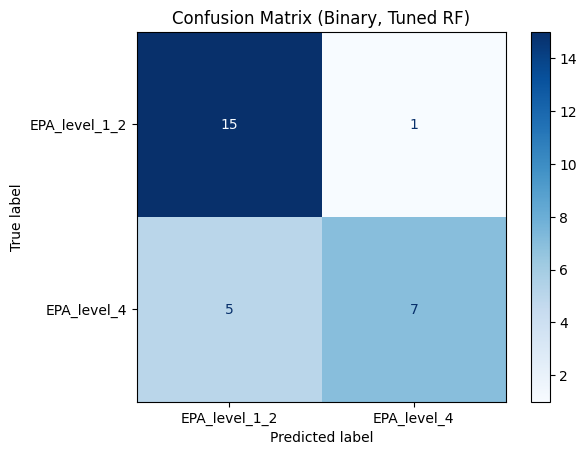

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best cross-validation F1: nan


In [31]:
# Confusion matrix for binary classification
cm_bin = confusion_matrix(y_test_bin, y_pred_bin, labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=['EPA_level_1_2', 'EPA_level_4'])
disp_bin.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Binary, Tuned RF)")
plt.show()

print("Best parameters:", grid_search_bin.best_params_)
print("Best cross-validation F1:", grid_search_bin.best_score_)